# 3 · LSTM multi-tarea — cuarta estimación

> **Tipo de ML:** `supervisado` · clases: `calor + frío` · input: secuencias de 24 h

## Cómo está organizado este notebook

| | Contenido | Cuándo se corre | Qué produce |
|---|---|---|---|
| **Parte A** | Entrenamiento final + evaluación + comparación con los modelos desplegados | **Siempre** que reentrenas | `LSTM_multitask.pt` + MLflow |
| **Parte B** | Laboratorio opcional: sensibilidad a hiperparámetros | **A veces**, para explorar | tabla de val por variante |
| **Parte C** | Clasificación vs regresión — decisión del índice continuo | Una vez, análisis de diseño | `LSTM_multitask_reg.pt` + decisión (C.4) |
| **Cierre** | Limitaciones y siguientes pasos | — | — |

La generación del dataset de secuencias (sección 2) procesa los `.nc` de ERA5 **una sola vez** y cachea el resultado; a partir de ahí es tan rápido como cargar un CSV.

## Decisiones de diseño

Las decisiones que gobiernan este notebook (detalle en `documentacion/diseño_modelo.md` §6 y `documentacion/formulas_ml_resumen.md`):

- **Por qué una LSTM además de XGBoost/RandomForest.** Los modelos actuales comen features agregadas (hora pico + estadísticas diarias) cuyas fórmulas (Heat Index, Wind Chill) están calibradas sobre población de EE. UU. La LSTM ve la **secuencia horaria cruda** de las 24 h y aprende la correlación empírica española directamente del label de MoMo — incluido el **alivio nocturno** (si la noche refrescó lo bastante para que el cuerpo se recupere), que la hora pico descarta por diseño.
- **Una sola red multi-tarea** (tronco LSTM compartido + 2 cabezas de 3 clases) en lugar de dos LSTM: calor y frío leen la misma física horaria, y la multi-tarea regulariza el tronco. Un único entrenamiento, un único `.pt`, ambas estimaciones en cada consulta.
- **Input crudo 24×5**: `t2m_c, rh, wind_speed_kmh, heat_index_c, wind_chill_c` por hora. **Sin UV**: los `.nc` de ERA5 descargados no traen radiación (limitación documentada). **Sin embeddings personales** (grasa/fototipo/sexo): descartados por ahora — MoMo es mortalidad poblacional sin atributos individuales, no recibirían ninguna señal de entrenamiento.
- **Split por fecha, nunca aleatorio** (un split aleatorio mezcla días de la misma ola entre train y test) + un tramo de **validación temporal** para el early stopping.
- **Pesos de clase `balanced`** en ambas pérdidas — sin ellos la red colapsa a la clase `seguro` (~90%), igual que le pasaba al XGBoost sin `sample_weight`.
- **Selección/comparación por `Rec_riesgo`** (recall medio de las clases 1-2): es un sistema de aviso, preferimos falsos positivos a no avisar de un día peligroso. La LSTM es la **cuarta estimación** del criterio más restrictivo — no necesita ganar a XGBoost/RF para ser útil, necesita cubrir el hueco del sesgo de calibración americana.

## 0. Entorno

In [1]:
# Verificar que el entorno está activo (torch viene del extra redes_neuronales)
import sys
print(f'Python: {sys.version}')
try:
    import torch
    print(f'PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
except ImportError:
    raise SystemExit('Falta PyTorch: corre  uv sync --extra redes_neuronales')


Python: 3.13.5 (main, May  5 2026, 21:05:52) [GCC 14.2.0]


PyTorch: 2.12.1+cu130  |  CUDA: False


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

import joblib

from climasafeai.utils.paths import (
    FIGURES_DIR, MODELS_DIR, PROCESSED_DATA_DIR, REPORTS_DIR,
)

# --- Dataset de secuencias 24h (con caché) ---
from climasafeai.data.sequences import (
    generar_dataset_secuencias, cargar_dataset_secuencias, split_secuencias_por_fecha,
)

# --- Parte A: entrenamiento y evaluación ---
from climasafeai.models.lstm_model import (
    train_lstm, evaluate_lstm, load_lstm, predict_lstm, escalar_secuencias,
    indice_riesgo_softmax, evaluate_lstm_regresion, LSTM_REG_MODEL_PATH,
)


## 2. Generar / cargar dataset de secuencias

La **primera** ejecución procesa los ~120 `.nc` mensuales de ERA5 (tarda unos minutos) y guarda `data/processed/secuencias_24h.npz`; las siguientes cargan el caché al instante. Usa `force=True` solo si cambiaste los datos crudos o las `feature_cols`.

In [3]:
generar_dataset_secuencias()   # no recalcula si el caché ya existe
data = cargar_dataset_secuencias()

X = data['X']
print(f"Secuencias: {X.shape}  ({X.shape[0]} días × {X.shape[1]} h × {X.shape[2]} vars: {data['feature_cols']})")
print(f"Fechas: {data['fechas'].min()} → {data['fechas'].max()}  |  Provincias: {len(np.unique(data['provincias']))}")
print(f"Balance calor (0=seguro, 1=precaución, 2=peligro): {np.bincount(data['y_calor'])}")
print(f"Balance frío:  {np.bincount(data['y_frio'])}")
assert not np.isnan(X).any(), 'El dataset de secuencias no debería contener NaN'


    Caché existente: /home/cacelas/Documentos/anfaia/ClimaSafeAI/data/processed/secuencias_24h.npz (usa force=True para regenerar)


Secuencias: (172350, 24, 5)  (172350 días × 24 h × 5 vars: [np.str_('t2m_c'), np.str_('rh'), np.str_('wind_speed_kmh'), np.str_('heat_index_c'), np.str_('wind_chill_c')])
Fechas: 2016-01-01 → 2026-06-26  |  Provincias: 45
Balance calor (0=seguro, 1=precaución, 2=peligro): [154322  10344   7684]
Balance frío:  [161772   5002   5576]


# Parte A · Entrenamiento final (camino habitual)

Entrena la LSTM con los hiperparámetros **ya decididos** (los defaults de `lstm_model.py`), la guarda en `models/` + MLflow, y la evalúa en el test temporal. **Esta es la parte que corres siempre.**

## 3. Configuración

Split temporal train/val/test (misma regla que `preprocess_data`: las últimas fechas van a test) y escalado con un `StandardScaler` **propio de las secuencias**, ajustado solo con train — el scaler diario existente se ajustó sobre la hora pico, otra distribución.

In [4]:
splits = split_secuencias_por_fecha(data, test_size=0.2, val_size=0.1)

scaler, X_train_s, X_val_s, X_test_s = escalar_secuencias(
    splits['X_train'], splits['X_val'], splits['X_test'],
)
print(f"Train: {X_train_s.shape}  |  Val: {X_val_s.shape}  |  Test: {X_test_s.shape}")


    Split por fecha: train hasta 2023-07-20 | val desde 2023-07-21 | test desde 2024-05-22 (766 días distintos de test)


    Scaler guardado → scaler_secuencias_lstm.joblib
Train: (124110, 24, 5)  |  Val: (13770, 24, 5)  |  Test: (34470, 24, 5)


## 4. Entrenar

Un único run `LSTM` en el experimento `climasafeai` de MLflow (levanta la UI con `make mlflow` si quieres seguirlo). Early stopping por val loss; se restaura el mejor checkpoint.

In [5]:
model, history = train_lstm(
    X_train_s, splits['y_train_calor'], splits['y_train_frio'],
    X_val_s,   splits['y_val_calor'],   splits['y_val_frio'],
    feature_cols=data['feature_cols'],
)


--> Entrenando LSTM multi-tarea en cpu (51846 parámetros)...


    época   1 | train_loss 1.7342 | val_loss 1.7662 | Rec_riesgo val calor 0.435 frío 0.476


    época   2 | train_loss 1.6718 | val_loss 1.8261 | Rec_riesgo val calor 0.477 frío 0.476


    época   3 | train_loss 1.6648 | val_loss 1.7697 | Rec_riesgo val calor 0.467 frío 0.441


    época   4 | train_loss 1.6555 | val_loss 1.7987 | Rec_riesgo val calor 0.482 frío 0.477


...

    Modelo guardado → LSTM_multitask.pt


2026/07/13 11:42:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


2026/07/13 11:42:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registered model 'climasafeai_LSTM_multitask' already exists. Creating a new version of this model...


Created version '5' of model 'climasafeai_LSTM_multitask'.


## 5. Evaluar

Métricas por cabeza con el mismo esquema que `evaluate_models` (la métrica de selección del proyecto es `Rec_riesgo`). Guarda `reports/resultados_lstm.csv` y las matrices de confusión.

In [6]:
# Curva de pérdida — si val se despega de train, hay sobreajuste
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['epoch'], history['train_loss'], label='train')
ax.plot(history['epoch'], history['val_loss'], label='val')
ax.set_xlabel('época'); ax.set_ylabel('pérdida conjunta (CE calor + CE frío)')
ax.set_title('LSTM multi-tarea — curva de pérdida')
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lstm_curva_perdida.png', dpi=150)
plt.show()


/tmp/ipykernel_17692/2098529241.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
df_lstm = evaluate_lstm(
    model,
    X_train_s, splits['y_train_calor'], splits['y_train_frio'],
    X_test_s,  splits['y_test_calor'],  splits['y_test_frio'],
)



--- LSTM_calor ---
  Accuracy  → train: 0.700 | test: 0.677
  F1 (w)    → train: 0.772  | test: 0.748
  F1_macro  → 0.409  | Rec_riesgo (clases 1..n) → 0.494

              precision    recall  f1-score   support

           0       0.98      0.70      0.82     30480
           1       0.09      0.15      0.11      2033
           2       0.18      0.83      0.29      1957

    accuracy                           0.68     34470
   macro avg       0.42      0.56      0.41     34470
weighted avg       0.88      0.68      0.75     34470

    cm_LSTM_calor.png guardado



--- LSTM_frio ---
  Accuracy  → train: 0.618 | test: 0.674
  F1 (w)    → train: 0.733  | test: 0.760
  F1_macro  → 0.397  | Rec_riesgo (clases 1..n) → 0.465

              precision    recall  f1-score   support

           0       0.99      0.69      0.82     31379
           1       0.08      0.32      0.12      1519
           2       0.16      0.61      0.25      1572

    accuracy                           0.67     34470
   macro avg       0.41      0.54      0.40     34470
weighted avg       0.91      0.67      0.76     34470

    cm_LSTM_frio.png guardado



  Resumen:
    Modelo  Acc_train  Acc_test  F1_train  F1_test  Prec_test  Rec_test  F1_macro  Rec_riesgo
LSTM_calor     0.6995    0.6774    0.7723   0.7476     0.8842    0.6774    0.4085      0.4939
 LSTM_frio     0.6179    0.6741    0.7325   0.7597     0.9107    0.6741    0.3972      0.4647

  Guardado → /home/cacelas/Documentos/anfaia/ClimaSafeAI/reports/resultados_lstm.csv


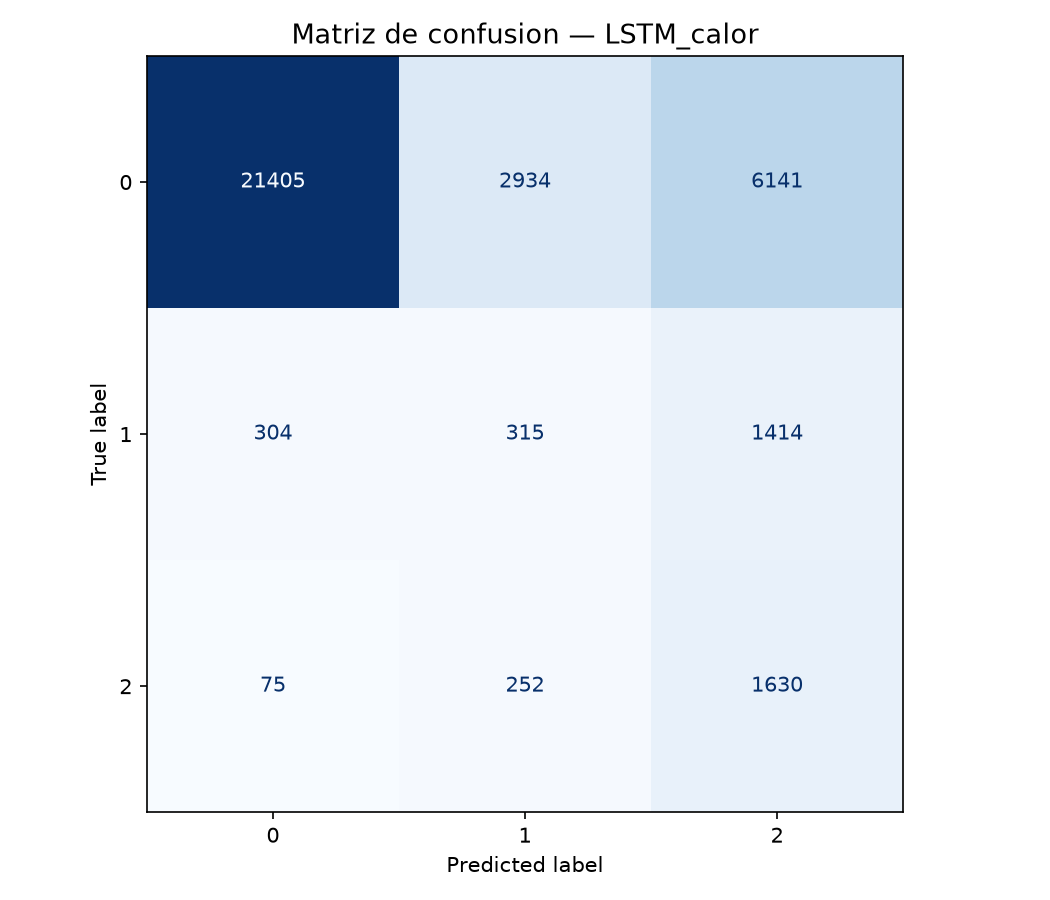

In [8]:
Image(FIGURES_DIR / 'cm_LSTM_calor.png')

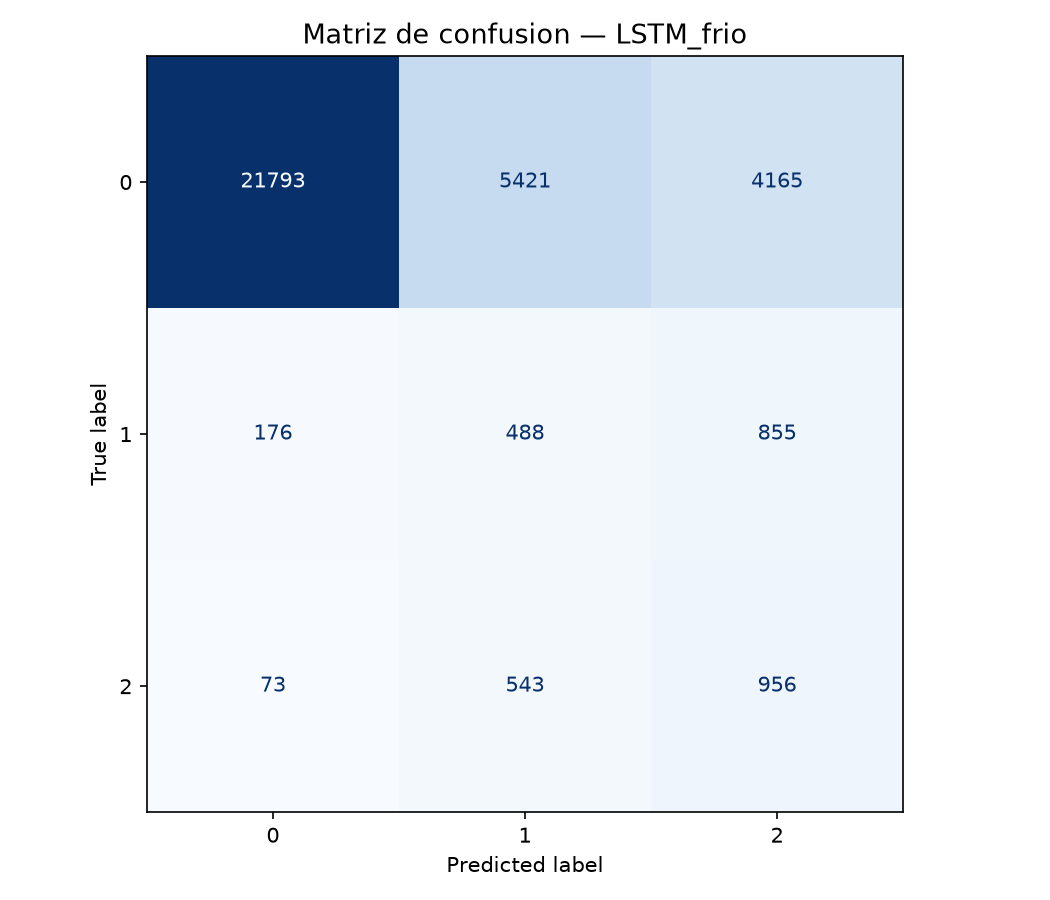

In [9]:
Image(FIGURES_DIR / 'cm_LSTM_frio.png')

## 6. Comparación con los modelos desplegados

Los desplegados hoy son **XGBoost (calor)** y **RandomForest (frío)**, elegidos por `Rec_riesgo` (notebooks 0-2). Aquí se **re-evalúan directamente** (`modelo_desplegado_{clase}.joblib` sobre sus `X_test_{clase}.csv`) en vez de leer `resultados_modelos.csv` — ese CSV lo sobrescribe el último 0-2 ejecutado y mezclaría clases.

> **Caveat honesto:** los test sets son *casi* los mismos (misma regla del último 20 % de fechas) pero no idénticos fila a fila — la LSTM descarta días con menos de 24 h y reserva un tramo de validación. La comparación es orientativa; la decisión de despliegue no se toma solo con esta tabla. Y recuerda el criterio del sistema (`diseño_modelo.md` §6): la LSTM **no sustituye** a nadie, es la cuarta estimación del criterio más restrictivo.

In [10]:
# Re-evaluación directa de los modelos desplegados, con las mismas métricas
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def _metricas_test(nombre, y_true, y_pred):
    risk = [c for c in np.unique(y_true) if c != 0]
    return {
        'Modelo': nombre,
        'Acc_test': round(accuracy_score(y_true, y_pred), 4),
        'Prec_test': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Rec_test': round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1_macro': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Rec_riesgo': round(recall_score(y_true, y_pred, labels=risk, average='macro', zero_division=0), 4),
        'F1_test': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

filas = []
for clase, nombre in [('calor', 'XGBoost_calor (desplegado)'), ('frio', 'RandomForest_frio (desplegado)')]:
    try:
        modelo = joblib.load(MODELS_DIR / f'modelo_desplegado_{clase}.joblib')
        X_te = pd.read_csv(PROCESSED_DATA_DIR / f'X_test_{clase}.csv')
        y_te = pd.read_csv(PROCESSED_DATA_DIR / f'y_test_{clase}.csv').squeeze()
        filas.append(_metricas_test(nombre, y_te, modelo.predict(X_te)))
    except FileNotFoundError as e:
        print(f'{clase}: no disponible ({e}) — corre antes los notebooks 0-1/0-2')

cols = ['Modelo', 'Acc_test', 'Prec_test', 'Rec_test', 'F1_macro', 'Rec_riesgo', 'F1_test']
tabla = pd.concat([pd.DataFrame(filas), df_lstm[cols]], ignore_index=True)
tabla[cols].sort_values('Rec_riesgo', ascending=False)


,Modelo,Acc_test,Prec_test,Rec_test,F1_macro,Rec_riesgo,F1_test
0,XGBoost_calor (desplegado),0.7936,0.9046,0.7936,0.5629,0.6331,0.8343
1,RandomForest_frio (desplegado),0.8106,0.9193,0.8106,0.5117,0.5256,0.8537
2,LSTM_calor,0.6774,0.8842,0.6774,0.4085,0.4939,0.7476
3,LSTM_frio,0.6741,0.9107,0.6741,0.3972,0.4647,0.7597


# Parte B · Laboratorio (opcional)

Igual que la Parte B de los notebooks 0-2: exploración que **no** corre en el camino habitual.

## B.1 · Sensibilidad a hiperparámetros

Variantes cortas (pocas épocas) para ver si la arquitectura por defecto está en el rango razonable. Como con el tuning del RandomForest: el ganador **se escribe a mano** como default en `lstm_model.py`, no se decide automáticamente aquí.

In [11]:
EJECUTAR_B1 = False  # ponlo a True para correr el barrido (varios minutos)

if EJECUTAR_B1:
    variantes = [
        {'hidden_size': 32,  'dropout': 0.3},
        {'hidden_size': 128, 'dropout': 0.3},
        {'hidden_size': 64,  'dropout': 0.1},
        {'hidden_size': 64,  'dropout': 0.5},
    ]
    filas = []
    for v in variantes:
        _, h = train_lstm(
            X_train_s, splits['y_train_calor'], splits['y_train_frio'],
            X_val_s,   splits['y_val_calor'],   splits['y_val_frio'],
            max_epochs=10, run_name=f"LSTM_h{v['hidden_size']}_d{v['dropout']}",
            feature_cols=data['feature_cols'], **v,
        )
        mejor = h.loc[h['val_loss'].idxmin()]
        filas.append({**v, 'val_loss': mejor['val_loss'],
                      'val_rec_calor': mejor['val_rec_riesgo_calor'],
                      'val_rec_frio': mejor['val_rec_riesgo_frio']})
    display(pd.DataFrame(filas))


# Parte C · Clasificación vs regresión

**Motivación** (propuesta del usuario, ver `diseño_modelo.md` §6): ¿debería la LSTM dar un **índice continuo de peligrosidad** en vez de 3 clases secas?

**Aclaración de escala importante:** el índice que puede aprender esta red es un *percentil de mortalidad poblacional 0-1* (el paso previo al corte p75/p95 de `labels.py`), **no** un Heat Index corregido en °C. Los coeficientes de las fórmulas NWS/OMS (tablas de categorías por °C, minutos hasta eritema por fototipo) viven en escala física y **no se pueden multiplicar por este índice** — no existe label de "HI corregido para España", MoMo da muertes. La modulación individual (fototipo, exposición) se compone como estimación aparte: sigue siendo el papel de la fórmula determinista dentro del criterio más restrictivo.

Se comparan **tres variantes** con evidencia:

| Variante | Salida | Coste |
|---|---|---|
| Clasificación (Parte A) | 3 clases (argmax) | ya entrenada |
| **Softmax de la clasificación** | índice 0-1 = `1 − P(seguro)` | gratis, sin reentrenar |
| **Regresión (nueva)** | índice 0-1 directo (percentil predicho) | reentrenar con target continuo |

Para comparar en igualdad, el índice de regresión se convierte a clases con los mismos cortes p75/p95 → misma tabla `Rec_riesgo`.

## C.1 · El clasificador ya da un índice continuo (softmax)

`P(riesgo) = 1 − P(seguro)` por cabeza. Ojo: con pesos de clase `balanced` las probabilidades salen infladas hacia el riesgo — como *índice* lo que importa es que **ordene** bien los días (lo mide el Spearman de C.3), no su valor absoluto.

In [12]:
idx_softmax_calor, idx_softmax_frio = indice_riesgo_softmax(model, X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, idx, y_clase, titulo in [
    (axes[0], idx_softmax_calor, splits['y_test_calor'], 'calor'),
    (axes[1], idx_softmax_frio, splits['y_test_frio'], 'frío'),
]:
    for clase, nombre in [(0, 'seguro'), (1, 'precaución'), (2, 'peligro')]:
        vals = idx[y_clase == clase]
        if len(vals):
            ax.hist(vals, bins=30, alpha=0.55, density=True, label=f'{nombre} (n={len(vals)})')
    ax.set_title(f'Índice softmax vs clase real — {titulo}')
    ax.set_xlabel('P(riesgo) = 1 − P(seguro)'); ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lstm_indice_softmax.png', dpi=150)
plt.show()


/tmp/ipykernel_17692/1177580594.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## C.2 · Entrenar la variante de regresión

Mismo tronco, mismos splits y mismo scaler; cambian las cabezas (1 salida + sigmoid) y la pérdida (MSE contra el percentil real de mortalidad, `y_*_pct`). Checkpoint propio (`LSTM_multitask_reg.pt`) — no pisa el clasificador.

In [13]:
model_reg, history_reg = train_lstm(
    X_train_s, splits['y_train_calor_pct'], splits['y_train_frio_pct'],
    X_val_s,   splits['y_val_calor_pct'],   splits['y_val_frio_pct'],
    modo='regresion', feature_cols=data['feature_cols'],
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_reg['epoch'], history_reg['train_loss'], label='train')
ax.plot(history_reg['epoch'], history_reg['val_loss'], label='val')
ax.set_xlabel('época'); ax.set_ylabel('pérdida conjunta (MSE calor + MSE frío)')
ax.set_title('LSTM regresión — curva de pérdida')
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lstm_reg_curva_perdida.png', dpi=150)
plt.show()


--> Entrenando LSTM multi-tarea en cpu (51586 parámetros)...


    época   1 | train_loss 0.0271 | val_loss 0.0349 | MAE val calor 0.0703 frío 0.0598


    época   2 | train_loss 0.0265 | val_loss 0.0353 | MAE val calor 0.0662 frío 0.0592


    época   3 | train_loss 0.0262 | val_loss 0.0351 | MAE val calor 0.0663 frío 0.0608


    época   4 | train_loss 0.0261 | val_loss 0.0347 | MAE val calor 0.0690 frío 0.0601


...

2026/07/13 11:45:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


2026/07/13 11:45:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registered model 'climasafeai_LSTM_multitask_reg' already exists. Creating a new version of this model...


Created version '3' of model 'climasafeai_LSTM_multitask_reg'.


/tmp/ipykernel_17692/2241765047.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## C.3 · Evaluación y comparación a tres bandas

Dos planos: como regresión (MAE, **Spearman** — ¿ordena bien los días por peligrosidad?) y como clasificador recuperado (percentil → clases con p75/p95 → `Rec_riesgo` comparable con la Parte A y los desplegados).

In [14]:
df_reg = evaluate_lstm_regresion(
    model_reg, X_test_s,
    splits['y_test_calor_pct'], splits['y_test_frio_pct'],
    splits['y_test_calor'], splits['y_test_frio'],
)



--- LSTM_reg_calor ---
  Regresión → MAE: 0.0800 | Spearman: 0.3356
  Clases (p75%/p95%) → Acc: 0.880 | F1_macro: 0.379 | Rec_riesgo: 0.076



              precision    recall  f1-score   support

           0       0.90      0.99      0.94     30480
           1       0.27      0.15      0.19      2033
           2       0.00      0.00      0.00      1957

    accuracy                           0.88     34470
   macro avg       0.39      0.38      0.38     34470
weighted avg       0.81      0.88      0.84     34470

    cm_LSTM_reg_calor.png guardado



--- LSTM_reg_frio ---
  Regresión → MAE: 0.0604 | Spearman: 0.2706
  Clases (p75%/p95%) → Acc: 0.910 | F1_macro: 0.318 | Rec_riesgo: 0.000

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     31379
           1       0.00      0.00      0.00      1519
           2       0.00      0.00      0.00      1572

    accuracy                           0.91     34470
   macro avg       0.30      0.33      0.32     34470
weighted avg       0.83      0.91      0.87     34470

    cm_LSTM_reg_frio.png guardado



  Resumen:
        Modelo    MAE  Spearman  Acc_test  F1_test  Prec_test  Rec_test  F1_macro  Rec_riesgo
LSTM_reg_calor 0.0800    0.3356    0.8802   0.8440     0.8130    0.8802    0.3787      0.0765
 LSTM_reg_frio 0.0604    0.2706    0.9103   0.8676     0.8287    0.9103    0.3177      0.0000

  Guardado → /home/cacelas/Documentos/anfaia/ClimaSafeAI/reports/resultados_lstm_reg.csv


In [15]:
# Spearman de AMBOS índices continuos contra el percentil real:
# ¿ordena mejor los días el softmax del clasificador o la regresión directa?
from scipy.stats import spearmanr
import torch

with torch.no_grad():
    pred_reg_calor, pred_reg_frio = [t.numpy() for t in model_reg(torch.tensor(X_test_s))]

comparacion_indices = pd.DataFrame([
    {'Índice': 'softmax clasificador', 'Spearman_calor': spearmanr(idx_softmax_calor, splits['y_test_calor_pct']).statistic,
     'Spearman_frio': spearmanr(idx_softmax_frio, splits['y_test_frio_pct']).statistic},
    {'Índice': 'regresión directa', 'Spearman_calor': spearmanr(pred_reg_calor, splits['y_test_calor_pct']).statistic,
     'Spearman_frio': spearmanr(pred_reg_frio, splits['y_test_frio_pct']).statistic},
]).round(4)
comparacion_indices


,Índice,Spearman_calor,Spearman_frio
0,softmax clasificador,0.3355,0.2197
1,regresión directa,0.3356,0.2706


In [16]:
# Tabla final: desplegados + clasificación + regresión, ordenada por Rec_riesgo
cols = ['Modelo', 'Acc_test', 'Prec_test', 'Rec_test', 'F1_macro', 'Rec_riesgo', 'F1_test']
tabla_final = pd.concat([tabla[cols], df_reg[cols]], ignore_index=True)
tabla_final.sort_values('Rec_riesgo', ascending=False)


,Modelo,Acc_test,Prec_test,Rec_test,F1_macro,Rec_riesgo,F1_test
0,XGBoost_calor (desplegado),0.7936,0.9046,0.7936,0.5629,0.6331,0.8343
1,RandomForest_frio (desplegado),0.8106,0.9193,0.8106,0.5117,0.5256,0.8537
2,LSTM_calor,0.6774,0.8842,0.6774,0.4085,0.4939,0.7476
3,LSTM_frio,0.6741,0.9107,0.6741,0.3972,0.4647,0.7597
4,LSTM_reg_calor,0.8802,0.8130,0.8802,0.3787,0.0765,0.8440
5,LSTM_reg_frio,0.9103,0.8287,0.9103,0.3177,0.0000,0.8676


## C.4 · Decisión

Criterios acordados de antemano (para que la decisión sea con evidencia y no con preferencia):

- Si la **regresión** no mejora ni el `Rec_riesgo` recuperado (tabla C.3) ni el Spearman del índice (tabla de índices), **se queda la clasificación** como cuarta estimación, con su **softmax como índice continuo** para producción (gratis y ya validado).
- Si la regresión gana claramente en Spearman (ordena mejor los días de peligro) aunque empate en clases, es la candidata a índice de producción.

**Resultado (ejecución 2026-07-10):** gana la **clasificación + softmax**.

| | Rec_riesgo calor | Rec_riesgo frío | Spearman calor | Spearman frío |
|---|---|---|---|---|
| Clasificación (+ softmax) | **0.532** | **0.505** | **0.347** | 0.185 |
| Regresión | 0.078 | 0.000 | 0.336 | **0.271** |

- La regresión **colapsa como sistema de aviso**: el MSE empuja las predicciones hacia la masa central del percentil (la mayoría de días), así que casi nunca supera el corte p75 → `Rec_riesgo` 0.08 (calor) y 0.00 (frío). Su accuracy "mejor" (0.88/0.91) es exactamente la trampa contra la que avisa `conclusiones_modelos.md`: acertar diciendo siempre "seguro".
- Como índice continuo, empata con el softmax en calor (0.336 vs 0.347) y ordena algo mejor el frío (0.271 vs 0.185) — un matiz interesante, pero no compensa perder la capacidad de aviso, y el softmax sale gratis del modelo ya desplegable.

**Decisión: la cuarta estimación sigue siendo la LSTM de clasificación; `indice_riesgo_softmax` queda como índice continuo 0-1 para producción.** El checkpoint de regresión (`LSTM_multitask_reg.pt`) se conserva como experimento documentado.

# Limitaciones y siguientes pasos (cierre)

- **Sin UV**: los `.nc` de ERA5 descargados no incluyen radiación; la parte de quemadura solar sigue cubierta solo por la fórmula determinista (con UV de Open UV en tiempo real). Pendiente: fuente de UV pronosticado (p. ej. CAMS) si el sistema pasa a predecir a varios días.
- **Labels = clases por percentiles de MoMo** (p75/p95 por provincia), no mortalidad cruda: la LSTM hereda esa definición de riesgo, igual que XGBoost/RF. El target continuo de regresión (`y_*_pct`) es ese mismo percentil sin cortar — y comparte el caveat de las clases: se calcula sobre TODO el histórico por provincia, así que hay una fuga leve train↔test heredada de la definición del label (no nueva de este notebook).
- **Pocas olas reales**: los días de peligro provienen de ~40-60 olas correlacionadas entre sí (`formulas_ml_resumen.md`) — la diversidad efectiva es menor de lo que sugiere el nº de filas; por eso la LSTM se trata como **modelo experimental**.
- **Integración**: para producción, `load_lstm()` + `predict_lstm()` devuelven ambas clases por día/provincia; el resultado final del sistema sigue siendo el **criterio más restrictivo** de las cuatro estimaciones (`diseño_modelo.md` §6).
- **Embeddings personales** (grasa, fototipo, sexo): reabrirlos solo cuando exista una fuente de datos individual (feedback en producción o cohortes con atributos) que pueda darles señal de entrenamiento.